### 07 EDA Analysis


Notebook ini melakukan Exploratory Data Analysis (EDA) untuk memahami pola impulsive buying berdasarkan waktu transaksi, kategori produk, serta faktor-faktor yang memengaruhi impulsive score pengguna menggunakan hasil feature engineering dan labeling. Analisis dilakukan untuk menjawab Business Question (BQ) utama serta memastikan kualitas dataset sebelum digunakan pada tahap machine learning dan model training.

Analisis utama yang dilakukan:

* Analisis distribusi label transaksi (AMAN, PERTIMBANGAN, IMPULSIF).
* Analisis pola impulsive buying berdasarkan waktu transaksi pengguna.
* Analisis kategori produk dengan kecenderungan impulsive buying tertinggi.
* Analisis pengaruh waktu transaksi, kategori produk, dan nilai transaksi terhadap impulsive score pengguna.
* Analisis pola spending berdasarkan nominal transaksi dan weekly spending behavior.
* Analisis driver utama penyebab impulsive buying.
* Analisis hubungan feature penting terhadap impulsive score.
* Pemeriksaan class imbalance, missing value, dan potensi bias dataset.

Business Question (BQ):

1. Bagaimana pola impulsive buying berdasarkan waktu transaksi pengguna?

2. Kategori produk apa yang memiliki kecenderungan impulsive buying paling tinggi?

3. Faktor apa yang paling memengaruhi impulsive score pengguna, seperti waktu transaksi, kategori produk, atau nilai transaksi?

Output utama di memory:

* `eda_label_distribution_df`: ringkasan distribusi label transaksi.
* `eda_time_analysis_df`: analisis impulsive buying berdasarkan waktu transaksi.
* `eda_category_analysis_df`: analisis impulsive buying berdasarkan kategori produk.
* `eda_feature_impact_df`: analisis pengaruh feature terhadap impulsive score.
* `eda_driver_analysis_df`: analisis driver utama impulsive buying.
* `eda_dataset_summary_df`: ringkasan perilaku transaksi per dataset.
* `eda_visual_ready_df`: dataset siap visualisasi dan model analysis.


### Import Library ###

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
import warnings
from google.colab import files
from openpyxl import load_workbook
from openpyxl.drawing.image import Image

### Konfigurasi Path dan Tampilan  

In [5]:
project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
eda_path = project_root / 'data' / 'eda'
alt.data_transformers.disable_max_rows()
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
warnings.filterwarnings('ignore')

print(f'Project root : {project_root}')
print(f'EDA path     : {eda_path}')
print('Mode         : display-only. Tidak ada file output yang disimpan.')

Project root : /content
EDA path     : /content/data/eda
Mode         : display-only. Tidak ada file output yang disimpan.


### Load Dataset Hasil Labeling

In [6]:
df = pd.read_csv('Merged_labeled_transaction.csv')

print(df.shape)
display(df.head())

(8497, 54)


,dataset_id,timestamp,tahun,bulan,tahun_bulan,tipe_transaksi,category,amount,metode_pembayaran,status_transaksi,sumber_file,source,hour,day_of_week,day_name,day_of_month,month,date_only,is_weekend,week_period,hour_sin,hour_cos,is_night,is_late_night,night_score,time_segment,category_score,category_type,is_hedonic_category,amount_log,amount_z,amount_score,amount_percentile,is_high_amount,user_proxy,transactions_same_day,daily_amount_total,share_of_daily_spend,amount_vs_weekly_avg,budget_limit,spent_so_far,budget_remaining_ratio,weekend_score,fingo_impulse_signal,signal_band,impulsive_score,label,is_impulsive,driver_night,driver_hedonic,driver_high_amount,driver_weekend,driver_count,main_driver
0,daily_household,2015-01-01 00:00:00,2015,1,2015-01,Expense,Transportasi,1830.0,Cash,Expense,daily_household_transactions_clean.csv,daily_household,0,3,Thursday,1,2015-01,2015-01-01,0,1,0.0,1.0,0,1,1.0,late_night,0.5,neutral,0,7.512618,-0.714176,0.380971,0.037520,0,daily_household_unknown_unknown,11,174216.0,0.010504,0.002797,1.261774e+07,1830.0,0.999855,0.0,0.595243,watch,48.929118,AMAN,0,True,False,False,False,1,night_time
1,daily_household,2015-01-01 00:00:00,2015,1,2015-01,Expense,Makanan,73200.0,Credit Card,Expense,daily_household_transactions_clean.csv,daily_household,0,3,Thursday,1,2015-01,2015-01-01,0,1,0.0,1.0,0,1,1.0,late_night,0.5,neutral,0,11.200964,2.380588,0.896765,0.694535,0,daily_household_unknown_unknown,11,174216.0,0.420168,0.111884,1.261774e+07,75030.0,0.994054,0.0,0.724191,high,64.402941,PERTIMBANGAN,0,True,False,True,False,2,night_time
2,daily_household,2015-01-01 00:00:00,2015,1,2015-01,Expense,Transportasi,3660.0,Cash,Expense,daily_household_transactions_clean.csv,daily_household,0,3,Thursday,1,2015-01,2015-01-01,0,1,0.0,1.0,0,1,1.0,late_night,0.5,neutral,0,8.205492,-0.634824,0.394196,0.116232,0,daily_household_unknown_unknown,11,174216.0,0.021008,0.005594,1.261774e+07,78690.0,0.993764,0.0,0.598549,watch,49.325882,AMAN,0,True,False,False,False,1,night_time
3,daily_household,2015-01-01 00:00:00,2015,1,2015-01,Expense,Transportasi,10980.0,Cash,Expense,daily_household_transactions_clean.csv,daily_household,0,3,Thursday,1,2015-01,2015-01-01,0,1,0.0,1.0,0,1,1.0,late_night,0.5,neutral,0,9.303922,-0.317412,0.447098,0.379894,0,daily_household_unknown_unknown,11,174216.0,0.063025,0.016783,1.261774e+07,89670.0,0.992893,0.0,0.611775,watch,50.912941,AMAN,0,True,False,False,False,1,night_time
4,daily_household,2015-01-01 00:00:00,2015,1,2015-01,Expense,Lainnya,7320.0,Cash,Expense,daily_household_transactions_clean.csv,daily_household,0,3,Thursday,1,2015-01,2015-01-01,0,1,0.0,1.0,0,1,1.0,late_night,0.5,neutral,0,8.898502,-0.476118,0.420647,0.296900,0,daily_household_unknown_unknown,11,174216.0,0.042017,0.011188,1.261774e+07,96990.0,0.992313,0.0,0.605162,watch,50.119412,AMAN,0,True,False,False,False,1,night_time


### EDA Analysis Function Helper

In [7]:
LABEL_ORDER = ['AMAN', 'PERTIMBANGAN', 'IMPULSIF']

def check_missing_values(data):
    return (
        data.isnull()
        .sum()
        .reset_index(name='missing_count')
        .rename(columns={'index': 'column'})
        .query('missing_count > 0')
        .sort_values('missing_count', ascending=False)
    )


def check_class_distribution(data):
    summary = data['label'].value_counts()

    summary = (
        summary
        .reindex(LABEL_ORDER, fill_value=0)
        .rename_axis('label')
        .reset_index(name='rows')
    )

    summary['share_pct'] = (
        summary['rows'] / len(data) * 100
    ).round(2)

    return summary


def analyze_time_pattern(data):
    return (
        data.groupby('hour')['is_impulsive']
        .mean()
        .mul(100)
        .reset_index(name='impulsive_rate')
    )


def analyze_category_pattern(data):
    return (
        data.groupby('category')['is_impulsive']
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .reset_index(name='impulsive_rate')
    )


def analyze_feature_impact(data, columns):
    summary = (
        data
        .groupby('label')[columns]
        .mean()
        .reindex(LABEL_ORDER)
        .reset_index()
    )

    return summary


def analyze_driver_pattern(data):
    return (
        data.groupby('main_driver')['is_impulsive']
        .mean()
        .mul(100)
        .reset_index(name='impulsive_rate')
        .sort_values('impulsive_rate', ascending=False)
    )


def create_correlation_matrix(data, columns):
    return data[columns].corr().round(2)

### Analisis Distribusi Label Transaksi   

In [8]:
eda_label_distribution_df = check_class_distribution(df)

display(eda_label_distribution_df)

,label,rows,share_pct
0,AMAN,5946,69.98
1,PERTIMBANGAN,1701,20.02
2,IMPULSIF,850,10.00


### Analisis Pola Impulsve Buying Berdasarkan Waktu Transaksi

In [9]:
eda_time_analysis_df = analyze_time_pattern(df)

display(eda_time_analysis_df.head())

,hour,impulsive_rate
0,0,14.222712
1,1,51.851852
2,2,33.333333
3,3,27.272727
4,4,15.000000


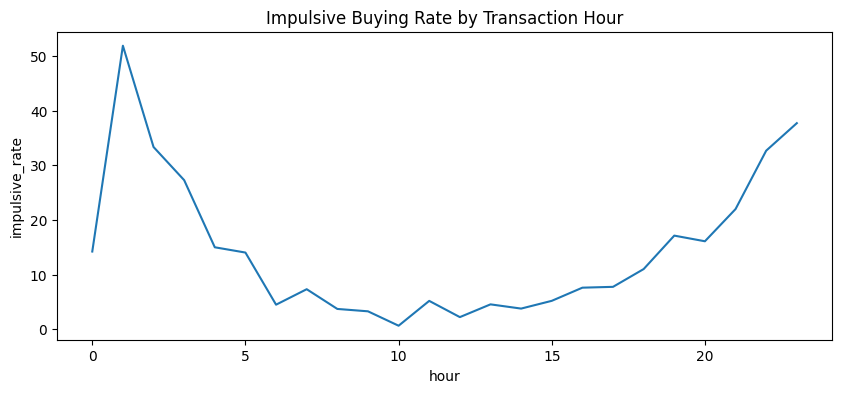

In [10]:
plt.figure(figsize=(10,4))

sns.lineplot(
    data=eda_time_analysis_df,
    x='hour',
    y='impulsive_rate'
)

plt.title('Impulsive Buying Rate by Transaction Hour')

plt.show()

### Analisis Kategori Porduk dengan Impulsive Buying

In [11]:
eda_category_analysis_df = analyze_category_pattern(df)

display(eda_category_analysis_df.head(10))

,category,impulsive_rate
0,Hiburan,32.867133
1,Lainnya,13.387097
2,Belanja,10.244941
3,Transportasi,5.720339
4,Makanan,4.075829
5,Kesehatan,1.102941


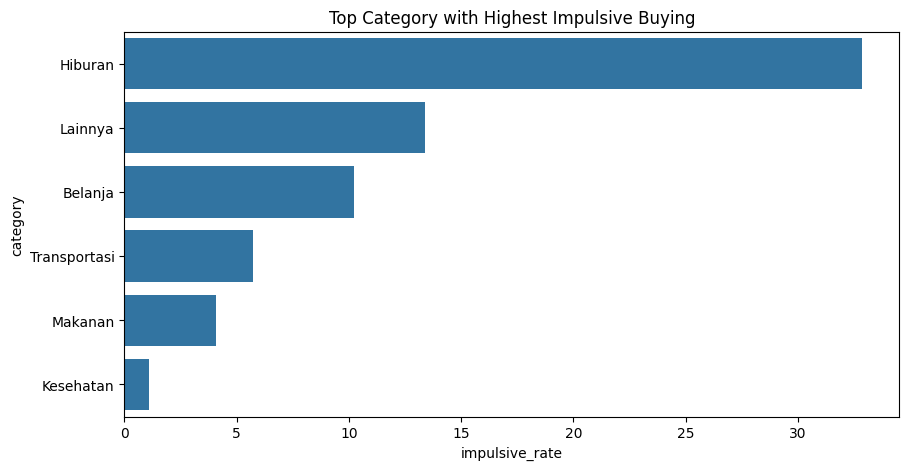

In [12]:
top_category_df = eda_category_analysis_df.head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_category_df,
    x='impulsive_rate',
    y='category'
)

plt.title('Top Category with Highest Impulsive Buying')
plt.show()

### Analisis Pengaruh Waktu, Kategori, dan Nilai Transaksi terhadap Impulsive Score

In [13]:
IMPORTANT_FEATURES = [
    'amount',
    'amount_vs_weekly_avg',
    'budget_remaining_ratio',
    'night_score',
    'category_score',
    'fingo_impulse_signal'
]

eda_feature_impact_df = analyze_feature_impact(
    df,
    IMPORTANT_FEATURES
)

display(eda_feature_impact_df)

,label,amount,amount_vs_weekly_avg,budget_remaining_ratio,night_score,category_score,fingo_impulse_signal
0,AMAN,114550.734361,0.606696,0.236630,0.448677,0.779347,0.533399
1,PERTIMBANGAN,370783.644474,1.172753,0.262564,0.781844,0.711346,0.710139
2,IMPULSIF,212735.828647,1.331513,0.156249,0.788235,0.808824,0.804884


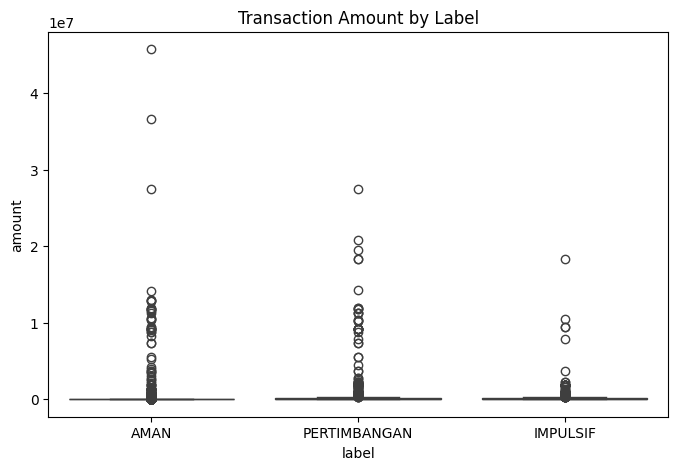

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='label',
    y='amount'
)

plt.title('Transaction Amount by Label')
plt.show()

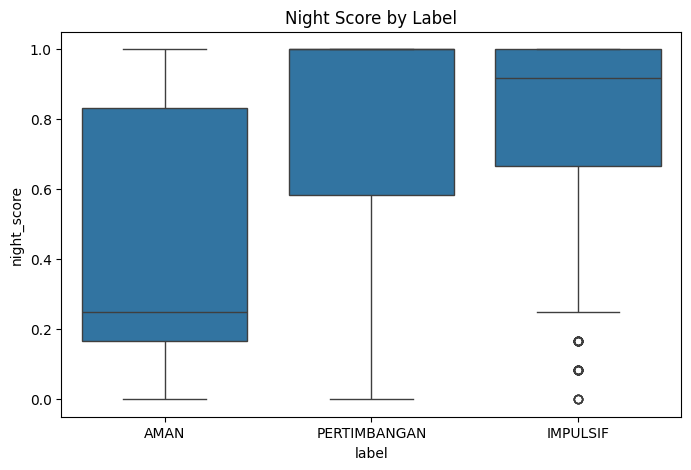

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='label',
    y='night_score'
)

plt.title('Night Score by Label')
plt.show()

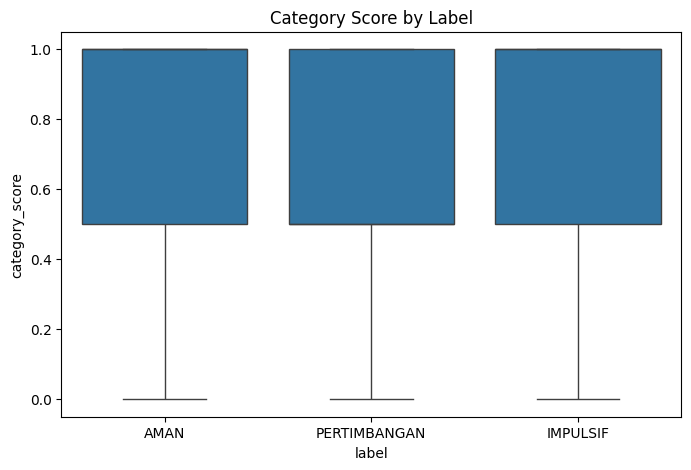

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='label',
    y='category_score'
)

plt.title('Category Score by Label')
plt.show()

### Analisis Spending Behavior dan Weekly Spending Pattern

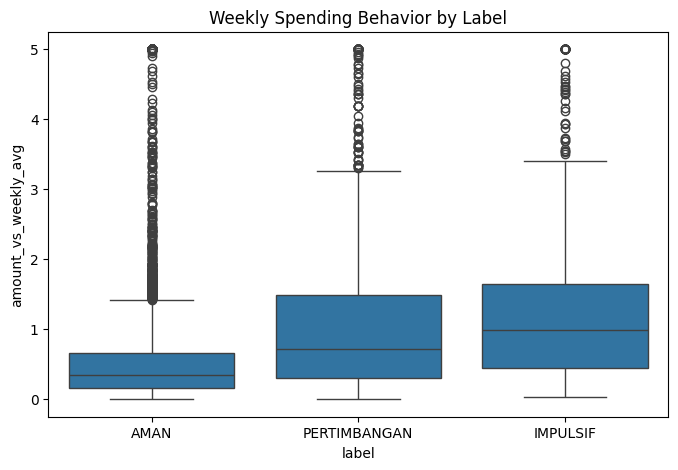

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='label',
    y='amount_vs_weekly_avg'
)

plt.title('Weekly Spending Behavior by Label')
plt.show()

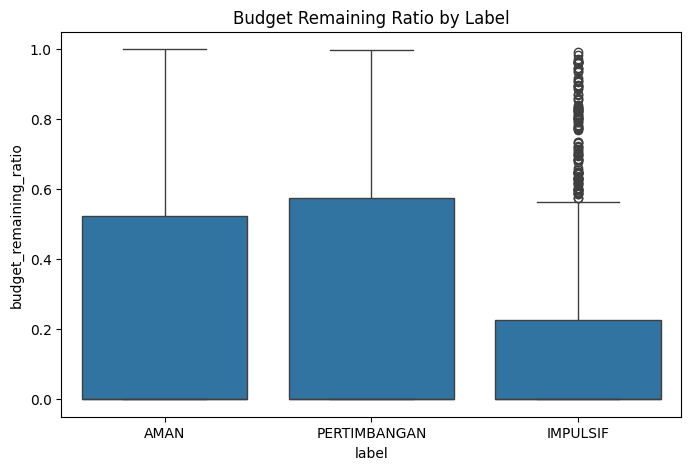

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='label',
    y='budget_remaining_ratio'
)

plt.title('Budget Remaining Ratio by Label')
plt.show()

### Analisis Driver Utama Penyebab Impulsive Buying

In [19]:
eda_driver_analysis_df = analyze_driver_pattern(df)
display(eda_driver_analysis_df)

,main_driver,impulsive_rate
3,night_time,11.107025
0,hedonic_category,10.913601
1,high_amount,9.661836
2,mixed_low_signal,0.000000
4,weekend,0.000000


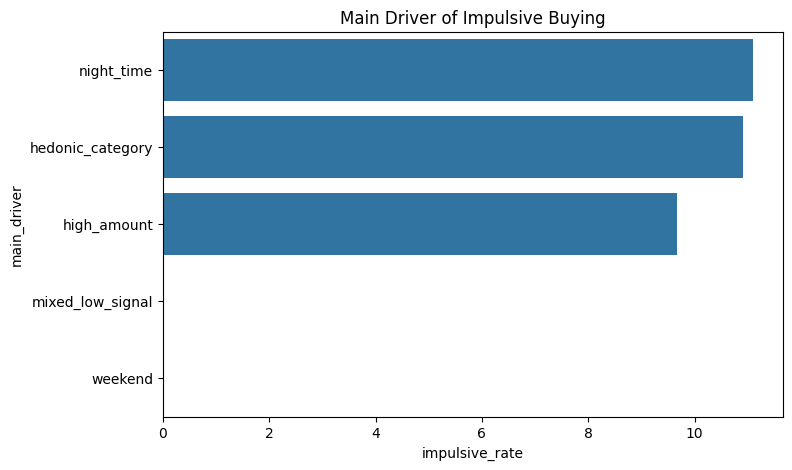

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=eda_driver_analysis_df,
    x='impulsive_rate',
    y='main_driver'
)

plt.title('Main Driver of Impulsive Buying')
plt.show()

### Analisis Hubungan Feature Penting terhadap Impulsive Score

In [21]:
eda_correlation_df = create_correlation_matrix(
    df,
    IMPORTANT_FEATURES
)

display(eda_correlation_df)

,amount,amount_vs_weekly_avg,budget_remaining_ratio,night_score,category_score,fingo_impulse_signal
amount,1.00,0.41,-0.05,0.01,-0.09,0.05
amount_vs_weekly_avg,0.41,1.00,-0.02,0.03,0.03,0.34
budget_remaining_ratio,-0.05,-0.02,1.00,0.30,-0.49,-0.03
night_score,0.01,0.03,0.30,1.00,-0.56,0.68
category_score,-0.09,0.03,-0.49,-0.56,1.00,0.04
fingo_impulse_signal,0.05,0.34,-0.03,0.68,0.04,1.00


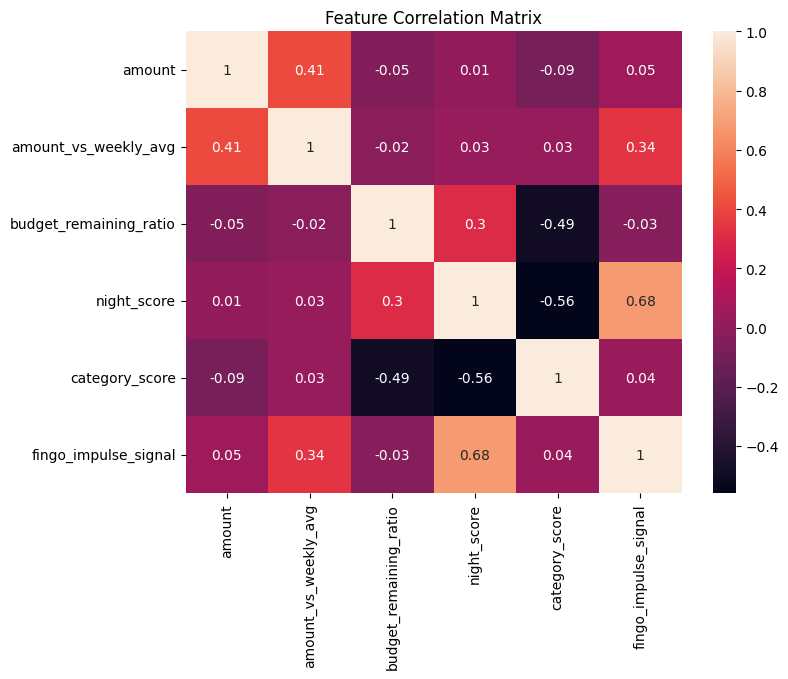

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(
    eda_correlation_df,
    annot=True
)

plt.title('Feature Correlation Matrix')
plt.show()

### Pemeriksaan Missing Value dan Potensi Bias Dataset

In [23]:
missing_value_df = check_missing_values(df)

display(missing_value_df)

,column,missing_count
8,metode_pembayaran,1500


In [24]:
df['metode_pembayaran'] = (
    df['metode_pembayaran']
    .fillna(df['metode_pembayaran'].mode()[0])
)

display(df[['metode_pembayaran']].head(20))
print(df['metode_pembayaran'].isnull().sum())

,metode_pembayaran
0,Cash
1,Credit Card
2,Cash
3,Cash
4,Cash
5,Cash
6,Cash
7,Cash
8,Cash
9,Cash


0


,dataset_id,impulsive_rate
0,daily_household,8.564437
1,ecommerce_sales,9.768977
2,personal_finance,13.066667


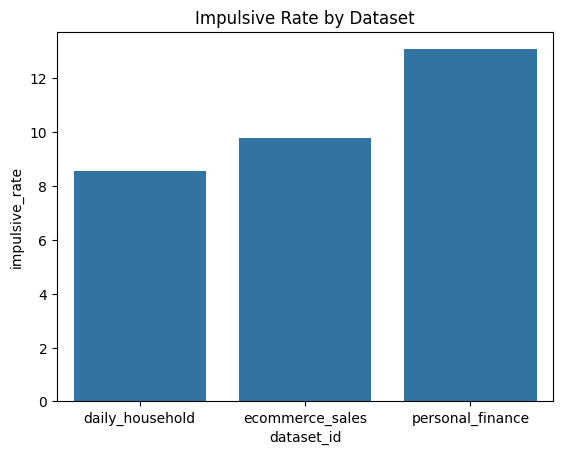

In [25]:
dataset_bias_df = (
    df.groupby('dataset_id')['is_impulsive']
    .mean()
    .mul(100)
    .reset_index(name='impulsive_rate')
)
display(dataset_bias_df)

sns.barplot(
    data=dataset_bias_df,
    x='dataset_id',
    y='impulsive_rate'
)

plt.title('Impulsive Rate by Dataset')
plt.show()

### Summary EDA analysis

In [26]:

excel_name = 'EDA_BQ_Analysis_Report.xlsx'

with pd.ExcelWriter(excel_name, engine='openpyxl') as writer:
    eda_label_distribution_df.to_excel(writer, sheet_name='Label_Distribution', index=False)
    eda_time_analysis_df.to_excel(writer, sheet_name='BQ1_Time_Analysis', index=False)
    eda_category_analysis_df.to_excel(writer, sheet_name='BQ2_Category_Analysis', index=False)
    eda_feature_impact_df.to_excel(writer, sheet_name='BQ3_Feature_Impact', index=False)
    eda_driver_analysis_df.to_excel(writer, sheet_name='Driver_Analysis', index=False)
    eda_correlation_df.to_excel(writer, sheet_name='Correlation', index=True)
    dataset_bias_df.to_excel(writer, sheet_name='Dataset_Bias', index=False)
    missing_value_df.to_excel(writer, sheet_name='Missing_Value', index=False)

plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x='label',
    order=LABEL_ORDER
)
plt.title('Label Distribution')
plt.savefig('label_distribution.png', bbox_inches='tight')
plt.close()

plt.figure(figsize=(10,4))
sns.lineplot(
    data=eda_time_analysis_df,
    x='hour',
    y='impulsive_rate'
)
plt.title('Impulsive Buying by Transaction Hour')
plt.savefig('time_analysis.png', bbox_inches='tight')
plt.close()

plt.figure(figsize=(10,5))
sns.barplot(
    data=eda_category_analysis_df.head(10),
    x='impulsive_rate',
    y='category'
)
plt.title('Top Impulsive Buying Categories')
plt.savefig('category_analysis.png', bbox_inches='tight')
plt.close()

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='label',
    y='amount'
)
plt.title('Transaction Amount by Label')
plt.savefig('amount_analysis.png', bbox_inches='tight')
plt.close()

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='label',
    y='night_score'
)
plt.title('Night Score by Label')
plt.savefig('night_score_analysis.png', bbox_inches='tight')
plt.close()

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='label',
    y='category_score'
)
plt.title('Category Score by Label')
plt.savefig('category_score_analysis.png', bbox_inches='tight')
plt.close()

heatmap_df = (
    df.groupby(['time_segment', 'category_type'])['fingo_impulse_signal']
    .mean()
    .reset_index()
    .pivot(
        index='category_type',
        columns='time_segment',
        values='fingo_impulse_signal'
    )
)

plt.figure(figsize=(10,5))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.2f'
)
plt.title('Impulsive Score by Time Segment and Category Type')
plt.savefig('feature_heatmap.png', bbox_inches='tight')
plt.close()

plt.figure(figsize=(8,5))
sns.barplot(
    data=eda_driver_analysis_df,
    x='impulsive_rate',
    y='main_driver'
)
plt.title('Main Driver of Impulsive Buying')
plt.savefig('driver_analysis.png', bbox_inches='tight')
plt.close()

plt.figure(figsize=(8,6))
sns.heatmap(
    eda_correlation_df,
    annot=True
)
plt.title('Feature Correlation Matrix')
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.close()

plt.figure(figsize=(8,5))
sns.barplot(
    data=dataset_bias_df,
    x='dataset_id',
    y='impulsive_rate'
)
plt.title('Impulsive Rate by Dataset')
plt.savefig('dataset_bias.png', bbox_inches='tight')
plt.close()

wb = load_workbook(excel_name)

wb['Label_Distribution'].add_image(
    Image('label_distribution.png'),
    'H2'
)

wb['BQ1_Time_Analysis'].add_image(
    Image('time_analysis.png'),
    'H2'
)

wb['BQ2_Category_Analysis'].add_image(
    Image('category_analysis.png'),
    'H2'
)

wb['BQ3_Feature_Impact'].add_image(
    Image('amount_analysis.png'),
    'H2'
)

wb['BQ3_Feature_Impact'].add_image(
    Image('night_score_analysis.png'),
    'H25'
)

wb['BQ3_Feature_Impact'].add_image(
    Image('category_score_analysis.png'),
    'H48'
)

wb['BQ3_Feature_Impact'].add_image(
    Image('feature_heatmap.png'),
    'H71'
)

wb['Driver_Analysis'].add_image(
    Image('driver_analysis.png'),
    'H2'
)

wb['Correlation'].add_image(
    Image('correlation_heatmap.png'),
    'H2'
)

wb['Dataset_Bias'].add_image(
    Image('dataset_bias.png'),
    'H2'
)

wb.save(excel_name)

files.download(excel_name)

print('EDA_BQ_Analysis_Report.xlsx berhasil disimpan')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

EDA_BQ_Analysis_Report.xlsx berhasil disimpan
